**Install:** `pip install -U langchain langchain-openai langgraph`

# 🎯 11. Agent Orchestration Patterns

Moving beyond simple multi-agent systems, we explore **production-grade orchestration** — supervisors, parallel execution, and hierarchical agent teams.

In this notebook:

1. **Supervisor-Worker** architecture
2. **Parallel agent execution**
3. **Hierarchical agents** — multi-level teams
4. **Planner-Executor-Worker pipeline**

In [ ]:
import os, json
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field
from typing import List, Literal
import operator

# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
# if not os.environ.get("OPENAI_API_KEY"):
#     import getpass
#     os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

LLM_MODEL   = "gpt-4o-mini"

llm = ChatOpenAI(model=LLM_MODEL, temperature=0)
print(f'Model: {LLM_MODEL}')

c:\Users\user\Desktop\ai-agents-course-me\venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Model: gpt-4o-mini


## 11.1 Supervisor-Worker Architecture

The supervisor pattern uses a central coordinator that:
- Receives the task
- Decides which worker to assign it to
- Collects results
- Decides if more work is needed

```
User → Supervisor  → Worker A ──┐                             
                   → Worker B ──┼── Supervisor → Final Answer 
                   → Worker C ──┘                             
```

<img src="images/supervisor-worker-arch.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

### 11.1.1 Without create_agent

In [ ]:
from typing import Annotated, TypedDict, List, Literal
import operator
import json

from IPython.display import display, Markdown

from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.errors import GraphRecursionError

DEFAULT_MAX_ITERATIONS = 4

def show_md(content: str) -> None:
    """Display formatted Markdown output inside a notebook."""
    display(Markdown(content))


class SupervisorState(TypedDict):
    messages: Annotated[list, operator.add]
    task: str
    assignments: list
    results: dict
    final_answer: str
    iteration: int
    max_iterations: int


class Assignment(BaseModel):
    worker: Literal["researcher", "coder", "reviewer"] = Field(
        description="Which worker to assign"
    )
    subtask: str = Field(
        description="What the worker should do"
    )


class SupervisorDecision(BaseModel):
    assignments: List[Assignment] = Field(
        default_factory=list,
        description="Tasks to assign to workers"
    )
    is_complete: bool = Field(
        description="Whether all work is done"
    )
    final_answer: str = Field(
        default="",
        description="Final answer if complete"
    )


supervisor_llm = llm.with_structured_output(SupervisorDecision)

# Helpers

def serialize_results(results: dict) -> str:
    """Convert worker results into readable JSON."""
    if not results:
        return "No results yet."

    return json.dumps(results, indent=2, ensure_ascii=False)


def has_worker_result(results: dict, worker: str) -> bool:
    """Check whether a specific worker has already produced a result."""
    return any(key.startswith(f"{worker}_") for key in results.keys())


def format_assignments(assignments: list) -> str:
    """Format assignments as Markdown bullets."""
    if not assignments:
        return "_No assignments._"

    return "\n".join(
        f"- **{assignment['worker']}**: {assignment['subtask']}"
        for assignment in assignments
    )


def synthesize_final_answer(state: SupervisorState) -> str:
    """Create the final answer from all worker results."""

    results_ctx = serialize_results(state.get("results", {}))

    show_md("🧩 **Synthesizer:** creating final answer from worker results...")

    response = llm.invoke([
        SystemMessage(content=(
            "You are the final synthesizer. "
            "Use the worker results to produce the final answer. "
            "Do not assign more tasks. "
            "If code is present, include the final clean version. "
            "If review feedback is present, incorporate it. "
            "Return a complete, polished answer."
        )),
        HumanMessage(content=(
            f"Main task:\n{state['task']}\n\n"
            f"Worker results:\n{results_ctx}"
        ))
    ])

    return response.content


# Nodes

def supervisor(state: SupervisorState) -> dict:
    """Central coordinator that assigns work or finalizes."""

    iteration = state.get("iteration", 0)
    max_iterations = state.get("max_iterations", DEFAULT_MAX_ITERATIONS)
    results = state.get("results", {}) or {}

    show_md(f"## 🔁 Iteration try {iteration + 1}/{max_iterations}")
    show_md("🧠 **Supervisor:** checking progress...")

    if has_worker_result(results, "coder") and has_worker_result(results, "reviewer"):
        show_md("✅ **Supervisor:** coder and reviewer results found. Finalizing.")

        return {
            "final_answer": synthesize_final_answer(state),
            "assignments": []
        }

    if iteration >= max_iterations:
        show_md("🛑 **Supervisor:** max iterations reached. Forcing final answer.")

        return {
            "final_answer": synthesize_final_answer(state),
            "assignments": []
        }

    results_ctx = serialize_results(results)

    decision = supervisor_llm.invoke([
        SystemMessage(content=(
            "You are a supervisor managing a team of workers: "
            "researcher finds information, coder writes code, reviewer reviews quality. "

            "Your job is to assign only the next necessary subtasks. "

            "Important workflow rules: "
            "1. If there are no results yet, you may assign researcher and/or coder. "
            "2. If code exists but no review exists, assign reviewer. "
            "3. If code and review both exist, mark is_complete=true. "
            "4. Do not assign reviewer more than once unless the previous review explicitly says "
            "that a serious defect must be fixed. "
            "5. If the existing results are enough, mark is_complete=true and provide final_answer. "
            "6. Never keep assigning tasks just to continue the loop."
        )),
        HumanMessage(content=(
            f"Main task:\n{state['task']}\n\n"
            f"Iteration try: {iteration + 1}/{max_iterations}\n\n"
            f"Results so far:\n{results_ctx}"
        ))
    ])

    if decision.is_complete:
        show_md("✅ **Supervisor:** work complete according to supervisor decision.")

        final_answer = decision.final_answer.strip()

        if not final_answer:
            show_md("⚠️ **Supervisor:** final answer was empty. Synthesizing instead.")
            final_answer = synthesize_final_answer(state)

        return {
            "final_answer": final_answer,
            "assignments": []
        }

    assignments = [
        {
            "worker": a.worker,
            "subtask": a.subtask
        }
        for a in decision.assignments
    ]

    # Guard 1: LLM says not complete but returns no assignments.
    # Finalize instead of silently ending with empty answer.
    if not assignments:
        show_md("⚠️ **Supervisor:** no assignments returned. Finalizing from current results.")

        return {
            "final_answer": synthesize_final_answer(state),
            "assignments": []
        }

    # Guard 2: avoid repeated reviewer loop.
    # If reviewer has already produced a result, do not assign
    # another reviewer again.
    filtered_assignments = []

    for assignment in assignments:
        worker = assignment["worker"]

        if worker == "reviewer" and has_worker_result(results, "reviewer"):
            show_md("⚠️ **Supervisor:** duplicate reviewer assignment removed.")
            continue

        filtered_assignments.append(assignment)

    if not filtered_assignments:
        show_md("⚠️ **Supervisor:** all assignments were duplicates. Finalizing.")

        return {
            "final_answer": synthesize_final_answer(state),
            "assignments": []
        }

    show_md(
        "📋 **Supervisor assigned:**\n\n"
        f"{format_assignments(filtered_assignments)}"
    )

    return {
        "assignments": filtered_assignments
    }


def workers(state: SupervisorState) -> dict:
    """Execute all assigned worker tasks."""

    results = dict(state.get("results", {}) or {})
    assignments = state.get("assignments", []) or []

    iteration = state.get("iteration", 0)
    max_iterations = state.get("max_iterations", DEFAULT_MAX_ITERATIONS)

    show_md(f"👷 **Workers running for iteration try {iteration + 1}/{max_iterations}**")

    worker_prompts = {
        "researcher": (
            "You are a research specialist. "
            "Find the key facts concisely and accurately."
        ),
        "coder": (
            "You are a Python developer. "
            "Write clean, documented, production-quality Python code."
        ),
        "reviewer": (
            "You are a quality reviewer. "
            "Review the provided work for correctness, clarity, edge cases, and code quality. "
            "Be concise but specific."
        )
    }

    results_ctx = serialize_results(results)

    for index, assignment in enumerate(assignments):
        worker = assignment["worker"]
        subtask = assignment["subtask"]
        prompt = worker_prompts.get(worker, "Complete the task.")

        show_md(
            f"▶️ **[{iteration + 1}/{max_iterations}] {worker} started**\n\n"
            f"> {subtask[:120]}"
        )

        response = llm.invoke([
            SystemMessage(content=prompt),
            HumanMessage(content=(
                f"Main task:\n{state['task']}\n\n"
                f"Your subtask:\n{subtask}\n\n"
                f"Results already produced by other workers:\n{results_ctx}"
            ))
        ])

        result_key = f"{worker}_iter_{iteration + 1}_task_{index}"
        results[result_key] = response.content

        show_md(
            f"✅ **[{iteration + 1}/{max_iterations}] {worker}: done** "
            f"`{len(response.content)} chars`"
        )

    return {
        "results": results,
        "assignments": [],
        "iteration": iteration + 1
    }


# Routing

def should_continue(state: SupervisorState) -> str:
    """Route after supervisor."""

    if state.get("final_answer"):
        return END

    if state.get("assignments"):
        return "workers"

    # This should normally not happen because supervisor finalizes
    # when there are no assignments, but it is a safe fallback.
    return END


# Build Graph
sup_graph = StateGraph(SupervisorState)
sup_graph.add_node("supervisor", supervisor)
sup_graph.add_node("workers", workers)
sup_graph.add_edge(START, "supervisor")
sup_graph.add_conditional_edges(
    "supervisor",
    should_continue,
    {
        "workers": "workers",
        END: END
    }
)
sup_graph.add_edge("workers", "supervisor")
sup_app = sup_graph.compile()
show_md("**Supervisor**-Worker system compiled!")

✅ **Supervisor-Worker system compiled!**

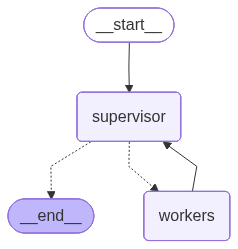

In [ ]:
from IPython.display import Image, display

display(Image(sup_app.get_graph().draw_mermaid_png()))

In [ ]:
# Run Example

initial_state: SupervisorState = {
    "messages": [],
    "task": (
        "Create a Python function that calculates compound interest, "
        "with documentation and a review."
    ),
    "assignments": [],
    "results": {},
    "final_answer": "",
    "iteration": 0,
    "max_iterations": 4
}


try:
    result = sup_app.invoke(
        initial_state,
        config={
            # Safety fuse only.
            # The real stopping logic is inside supervisor().
            "recursion_limit": 20
        }
    )

    show_md("# === FINAL ANSWER ===")

    if result.get("final_answer"):
        display(Markdown(result["final_answer"]))
    else:
        show_md(
            "[!] **No final answer was produced.**\n\n"
            "## Worker Results\n\n"
            f"```json\n{json.dumps(result.get('results', {}), indent=2, ensure_ascii=False)}\n```"
        )

except GraphRecursionError:
    show_md(
        "[X] **Graph stopped because it hit the recursion limit.**\n\n"
        "This means the graph did not reach a valid `END` state."
    )

## 🔁 Iteration try 1/4

🧠 **Supervisor:** checking progress...

📋 **Supervisor assigned:**

- **researcher**: Find information on how to calculate compound interest and the formula used.
- **coder**: Write a Python function that calculates compound interest.

👷 **Workers running for iteration try 1/4**

▶️ **[1/4] researcher started**

> Find information on how to calculate compound interest and the formula used.

...

🧠 **Supervisor:** checking progress...

✅ **Supervisor:** coder and reviewer results found. Finalizing.

🧩 **Synthesizer:** creating final answer from worker results...

# === FINAL ANSWER ===

Here is a polished Python function that calculates compound interest, incorporating feedback and improvements from the review process. The function includes input validation, type hints, and comprehensive documentation.

```python
def calculate_compound_interest(principal: float, annual_rate: float, times_compounded: int, years: int) -> tuple:
    """
    Calculate the compound interest and total amount after interest.

    Parameters:
    principal (float): The initial amount of money (the principal).
    annual_rate (float): The annual interest rate (in percentage).
    times_compounded (int): The number of times that interest is compounded per year.
    years (int): The number of years the money is invested or borrowed.

    Returns:
    tuple: A tuple containing:
        - float: The total amount after interest.
        - float: The compound interest earned.
    
    Raises:
    ValueError: If any input is negative or if times_compounded is zero or negative.
    """
    # Input validation
    if principal < 0:
        raise ValueError("Principal amount cannot be negative.")
    if annual_rate < 0:
        raise ValueError("Annual interest rate cannot be negative.")
    if times_compounded <= 0:
        raise ValueError("Compounding frequency must be a positive integer.")
    if years < 0:
        raise ValueError("Number of years cannot be negative.")

    # Convert annual rate from percentage to decimal
    rate_decimal = annual_rate / 100
    
    # Calculate the total amount after interest
    total_amount = principal * (1 + rate_decimal / times_compounded) ** (times_compounded * years)
    
    # Calculate compound interest
    compound_interest = total_amount - principal
    
    return total_amount, compound_interest

# Example usage:
if __name__ == "__main__":
    principal_amount = 1000  # Example principal
    annual_interest_rate = 5  # Example interest rate in percentage
    compounding_frequency = 4  # Quarterly
    investment_duration = 10  # 10 years

    total, interest = calculate_compound_interest(principal_amount, annual_interest_rate, compounding_frequency, investment_duration)
    print(f"Total Amount: ${total:.2f}")
    print(f"Compound Interest Earned: ${interest:.2f}")
```

### Key Features of the Function:
1. **Functionality**: The function calculates both the total amount after interest and the compound interest earned.
2. **Input Validation**: It checks for negative values and ensures that the compounding frequency is a positive integer, raising appropriate errors if the inputs are invalid.
3. **Type Hints**: The function uses type hints for better readability and static type checking.
4. **Documentation**: The docstring provides clear descriptions of parameters, return values, and potential exceptions, enhancing usability for other developers.
5. **Example Usage**: An example is included to demonstrate how to use the function, which is helpful for users unfamiliar with the implementation.

This implementation is robust, user-friendly, and suitable for integration into larger financial applications or personal finance calculations.

### 11.1.2 With create_agent

In [ ]:
from typing import Literal, List, Annotated
from typing_extensions import TypedDict
import operator
import json

from IPython.display import display, Markdown, Image

from pydantic import BaseModel, Field
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.errors import GraphRecursionError
from langchain.agents import create_agent


# Ηelpers

def show_md(text: str) -> None:
    display(Markdown(text))


def to_json(data) -> str:
    return json.dumps(data, indent=2, ensure_ascii=False)


DEFAULT_MAX_ITERATIONS = 4

# Tools
@tool
def search(query: str) -> str:
    """Search a knowledge base, simulated for this example."""
    return f"[search results for: {query}]"


# Worker agents

researcher = create_agent(
    model=llm,
    tools=[search],
    system_prompt=(
        "You are a researcher. "
        "Gather only the information needed for the assigned subtask. "
        "Use search when useful. Be concise and practical."
    ),
)

coder = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "You are a senior Python developer. "
        "Write clean, documented, production-quality Python code. "
        "Prefer simple, readable implementations with clear docstrings."
    ),
)

reviewer = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "You are a code reviewer. "
        "Critique code for correctness, clarity, style, edge cases, and API design. "
        "Be concise but specific."
    ),
)

WORKERS = {
    "researcher": researcher,
    "coder": coder,
    "reviewer": reviewer,
}


# State
class SupervisorState(TypedDict):
    messages: Annotated[list, operator.add]
    task: str
    assignments: list
    results: dict
    final_answer: str
    iteration: int
    max_iterations: int


# Structured output models

class Assignment(BaseModel):
    worker: Literal["researcher", "coder", "reviewer"] = Field(
        description="Which worker should handle the subtask."
    )
    subtask: str = Field(
        description="The concrete subtask assigned to the worker."
    )


class SupervisorPlan(BaseModel):
    assignments: List[Assignment] = Field(
        default_factory=list,
        description="The next worker assignments."
    )
    final_answer: str = Field(
        default="",
        description="Final answer if the work is complete."
    )


planner = llm.with_structured_output(SupervisorPlan)


# Helpers
def serialize_results(results: dict) -> str:
    if not results:
        return "No results yet."

    return json.dumps(results, indent=2, ensure_ascii=False)


def has_worker_result(results: dict, worker: str) -> bool:
    return any(key.startswith(f"{worker}_") for key in results.keys())


def format_assignments(assignments: list) -> str:
    if not assignments:
        return "_No assignments._"

    return "\n".join(
        f"- **{a['worker']}**: {a['subtask']}"
        for a in assignments
    )


def get_last_message_content(agent_output) -> str:
    """
    create_agent().invoke(...) usually returns a dict with a 'messages' list.
    The final message content is the worker's final answer.
    """
    messages = agent_output.get("messages", [])

    if not messages:
        return ""

    return messages[-1].content


def synthesize_final_answer(state: SupervisorState) -> str:
    """Create final answer from all worker outputs."""

    show_md("🧩 **Synthesizer:** creating final answer from worker results...")

    results_ctx = serialize_results(state.get("results", {}))

    response = llm.invoke([
        SystemMessage(content=(
            "You are the final synthesizer. "
            "Use the worker results to produce the final answer. "
            "Do not assign more tasks. "
            "If code is present, include the final clean version. "
            "If review feedback is present, incorporate it. "
            "Return a complete, polished answer."
        )),
        HumanMessage(content=(
            f"Main task:\n{state['task']}\n\n"
            f"Worker results:\n{results_ctx}"
        ))
    ])

    return response.content


# Graph nodes

def supervisor(state: SupervisorState) -> dict:
    """
    LLM-based supervisor with deterministic guards.
    It can assign subtasks or finalize the whole workflow.
    """

    iteration = state.get("iteration", 0)
    max_iterations = state.get("max_iterations", DEFAULT_MAX_ITERATIONS)
    results = state.get("results", {}) or {}

    show_md(f"## 🔁 Iteration try {iteration + 1}/{max_iterations}")
    show_md("🧠 **Supervisor:** checking progress...")

    # Deterministic stop:
    # If we already have code and review, finalize.
    if has_worker_result(results, "coder") and has_worker_result(results, "reviewer"):
        show_md("✅ **Supervisor:** coder and reviewer results found. Finalizing.")

        return {
            "assignments": [],
            "final_answer": synthesize_final_answer(state)
        }

    # Hard stop:
    # Do not simply END. First synthesize a final answer.
    if iteration >= max_iterations:
        show_md("🛑 **Supervisor:** max iterations reached. Forcing final answer.")

        return {
            "assignments": [],
            "final_answer": synthesize_final_answer(state)
        }

    prior = serialize_results(results)

    plan = planner.invoke([
        SystemMessage(content=(
            "You are a supervisor managing workers: researcher, coder, reviewer. "

            "Your job is to assign only the next necessary subtasks. "

            "Workflow rules: "
            "1. If there are no results yet, assign researcher and coder if useful. "
            "2. If code exists but review does not exist, assign reviewer. "
            "3. If code and review both exist, provide final_answer and no assignments. "
            "4. Do not assign reviewer repeatedly. "
            "5. Do not assign the same worker again unless there is a clear reason. "
            "6. If the existing results are enough, provide final_answer."
        )),
        HumanMessage(content=(
            f"Main task:\n{state['task']}\n\n"
            f"Iteration try: {iteration + 1}/{max_iterations}\n\n"
            f"Done so far:\n{prior}"
        )),
    ])

    # If supervisor provides final answer, finish.
    if plan.final_answer.strip():
        show_md("✅ **Supervisor:** final answer produced by planner.")

        return {
            "assignments": [],
            "final_answer": plan.final_answer.strip()
        }

    assignments = [a.model_dump() for a in plan.assignments]

    # Guard: no assignments and no final answer.
    if not assignments:
        show_md("⚠️ **Supervisor:** no assignments returned. Synthesizing final answer.")

        return {
            "assignments": [],
            "final_answer": synthesize_final_answer(state)
        }

    # Guard: avoid repeated reviewer loop.
    filtered_assignments = []

    for assignment in assignments:
        worker = assignment["worker"]

        if worker == "reviewer" and has_worker_result(results, "reviewer"):
            show_md("⚠️ **Supervisor:** duplicate reviewer assignment removed.")
            continue

        if worker == "coder" and has_worker_result(results, "coder"):
            show_md("⚠️ **Supervisor:** duplicate coder assignment removed.")
            continue

        filtered_assignments.append(assignment)

    if not filtered_assignments:
        show_md("⚠️ **Supervisor:** all assignments were duplicates. Finalizing.")

        return {
            "assignments": [],
            "final_answer": synthesize_final_answer(state)
        }

    show_md(
        "📋 **Supervisor assigned:**\n\n"
        f"{format_assignments(filtered_assignments)}"
    )

    return {
        "assignments": filtered_assignments,
        "final_answer": ""
    }


def dispatch(state: SupervisorState) -> dict:
    """
    Invoke each assigned create_agent worker independently.
    """

    iteration = state.get("iteration", 0)
    max_iterations = state.get("max_iterations", DEFAULT_MAX_ITERATIONS)

    results = dict(state.get("results", {}) or {})
    assignments = state.get("assignments", []) or []

    show_md(f"👷 **Dispatch running for iteration try {iteration + 1}/{max_iterations}**")

    results_ctx = serialize_results(results)

    for index, assignment in enumerate(assignments):
        worker = assignment["worker"]
        subtask = assignment["subtask"]

        agent = WORKERS[worker]

        show_md(
            f"▶️ **[{iteration + 1}/{max_iterations}] {worker} started**\n\n"
            f"> {subtask}"
        )

        agent_input = {
            "messages": [
                HumanMessage(content=(
                    f"Main task:\n{state['task']}\n\n"
                    f"Your subtask:\n{subtask}\n\n"
                    f"Results already produced by other workers:\n{results_ctx}"
                ))
            ]
        }

        out = agent.invoke(agent_input)
        content = get_last_message_content(out)
        result_key = f"{worker}_iter_{iteration + 1}_task_{index}"
        results[result_key] = content

        show_md(
            f"✅ **[{iteration + 1}/{max_iterations}] {worker}: done** "
            f"`{len(content)} chars`"
        )

    return {
        "results": results,
        "assignments": [],
        "iteration": iteration + 1
    }


# Routing
def is_done(state: SupervisorState) -> str:
    """
    Route after supervisor.
    END only when final_answer exists.
    """

    if state.get("final_answer"):
        return END

    if state.get("assignments"):
        return "dispatch"

    return END

# Build graph
g = StateGraph(SupervisorState)
g.add_node("supervisor", supervisor)
g.add_node("dispatch", dispatch)
g.add_edge(START, "supervisor")
g.add_conditional_edges(
    "supervisor",
    is_done,
    {
        "dispatch": "dispatch",
        END: END
    }
)
g.add_edge("dispatch", "supervisor")
sup_app = g.compile()

show_md("**Supervisor-worker graph compiled successfully.")

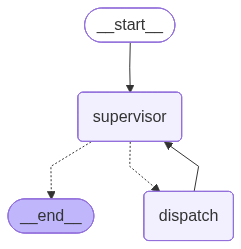

In [ ]:
display(Image(sup_app.get_graph().draw_mermaid_png()))

In [ ]:
# Run
initial_state: SupervisorState = {
    "messages": [],
    "task": (
        "Create a Python function that calculates compound interest, "
        "with documentation and a review."
    ),
    "assignments": [],
    "results": {},
    "final_answer": "",
    "iteration": 0,
    "max_iterations": 4
}
try:
    result = sup_app.invoke(
        initial_state,
        config={
            "recursion_limit": 20
        }
    )

    show_md("# === FINAL ANSWER ===")

    if result.get("final_answer"):
        display(Markdown(result["final_answer"]))
    else:
        show_md(
            "⚠️ **No final answer was produced.**\n\n"
            "## Worker Results\n\n"
            f"```json\n{to_json(result.get('results', {}))}\n```"
        )

except GraphRecursionError:
    show_md(
        "❌ **Graph stopped because it hit the recursion limit.**\n\n"
        "This usually means the graph loop did not reach a valid termination condition."
    )

## 🔁 Iteration try 1/4

🧠 **Supervisor:** checking progress...

📋 **Supervisor assigned:**

- **researcher**: Research the formula for calculating compound interest and best practices for implementing it in Python.
- **coder**: Write a Python function that calculates compound interest based on the researched formula.

👷 **Dispatch running for iteration try 1/4**

▶️ **[1/4] researcher started**

> Research the formula for calculating compound interest and best practices for implementing it in Python.

...

🧠 **Supervisor:** checking progress...

✅ **Supervisor:** coder and reviewer results found. Finalizing.

🧩 **Synthesizer:** creating final answer from worker results...

# === FINAL ANSWER ===

Here is the final implementation of the Python function to calculate compound interest, incorporating the feedback and suggestions from the review:

```python
def calculate_compound_interest(principal: float, annual_rate: float, times_compounded: int, years: float) -> float:
    """
    Calculate the future value of an investment based on compound interest.

    Parameters:
    principal (float): The initial amount of money (the principal).
    annual_rate (float): The annual interest rate (as a decimal, e.g., 0.05 for 5%).
    times_compounded (int): The number of times that interest is compounded per year.
    years (float): The number of years the money is invested or borrowed.

    Returns:
    float: The future value of the investment, including interest.
    
    Raises:
    ValueError: If any of the input values are negative or if times_compounded is zero.
    """
    
    if principal < 0:
        raise ValueError("Principal must be non-negative.")
    if annual_rate < 0:
        raise ValueError("Annual rate must be non-negative.")
    if times_compounded <= 0:
        raise ValueError("Times compounded must be positive.")
    if years < 0:
        raise ValueError("Years must be non-negative.")
    
    # Calculate the future value using the compound interest formula
    future_value = principal * (1 + annual_rate / times_compounded) ** (times_compounded * years)
    
    return future_value

# Example usage:
if __name__ == "__main__":
    try:
        principal_amount = 1000  # Initial investment
        annual_interest_rate = 0.05  # 5% interest rate
        compounding_frequency = 4  # Quarterly
        investment_duration = 5  # 5 years

        future_value = calculate_compound_interest(principal_amount, annual_interest_rate, compounding_frequency, investment_duration)
        print(f"The future value of the investment is: ${future_value:.2f}")
    except ValueError as e:
        print(f"Error: {e}")
```

### Key Improvements Made:
1. **Type Annotations**: Added type hints to the function signature for better clarity and static type checking.
2. **Specific Error Messages**: Enhanced error messages for each parameter to provide clearer feedback on input issues.
3. **Robustness**: The function now includes checks for negative values and zero for `times_compounded`, ensuring that it handles invalid inputs gracefully.
4. **Documentation**: The docstring is comprehensive, clearly explaining the function's purpose, parameters, return value, and exceptions.
5. **Example Usage**: The example demonstrates how to call the function and handle potential errors effectively.

This implementation adheres to best practices in Python programming and is suitable for production use.

## 11.2 Parallel Agent Execution

Sometimes sub-tasks are **independent** and can run simultaneously. This reduces latency dramatically.

| Sequential | Parallel |
|-----------|----------|
| Agent A (3s) → Agent B (3s) → Agent C (3s) = **9s** | A+B+C simultaneously = **3s** |

<img src="images/parallel-agent-execution.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

#### 11.2.1 

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import json

def run_parallel_agents(task: str) -> dict:
    specialists = {
        "technical": "Analyze the technical feasibility. Focus on implementation challenges.",
        "business": "Analyze the business impact. Focus on ROI and market opportunity.",
        "risk": "Analyze the risks. Focus on potential failures and mitigations.",
    }

    results = {}

    def run_specialist(name: str, prompt: str) -> tuple[str, str]:
        response = llm.invoke([
            SystemMessage(content=prompt),
            HumanMessage(content=f"Analyze this in 3 bullet points: {task}")
        ])
        return name, response.content

    with ThreadPoolExecutor(max_workers=3) as executor:
        futures = {
            executor.submit(run_specialist, name, prompt): name
            for name, prompt in specialists.items()
        }

        for future in as_completed(futures):
            name, result = future.result()
            results[name] = result
            print(f"✓ {name} done")

    agg = llm.invoke([
        SystemMessage(content="Synthesize these three analyses into a concise executive summary."),
        HumanMessage(content=json.dumps(results, indent=2))
    ])

    return {
        "analyses": results,
        "summary": agg.content
    }

In [ ]:
result = run_parallel_agents('Building an AI-powered customer support system that handles 10K queries/day')
display(Markdown(f'\n\n{result["summary"]}'))

✓ risk done
✓ business done
✓ technical done




**Executive Summary**

The implementation of an AI-powered customer support system presents significant opportunities and challenges for businesses aiming to enhance operational efficiency and customer satisfaction. 

**Key Risks:**
1. **Understanding Queries**: The AI may misinterpret complex customer inquiries, necessitating a robust training dataset and a fallback mechanism to human agents for unresolved issues.
2. **Scalability and Performance**: Handling high volumes of queries (up to 10,000 daily) could lead to system overload. Mitigation strategies include scalable cloud infrastructure and regular load testing.
3. **Data Privacy and Security**: Risks of exposing sensitive information or data breaches require strong encryption, compliance with regulations (e.g., GDPR), and regular security audits.

**Business Benefits:**
1. **Cost Reduction and ROI**: Automating responses can significantly lower operational costs and improve ROI by reallocating human resources to more complex tasks.
2. **Enhanced Customer Experience**: The AI system's 24/7 availability and instant responses can boost customer satisfaction and retention, leading to increased sales and insights for service improvement.
3. **Market Opportunity**: Adopting AI positions businesses as industry leaders, attracting tech-savvy customers and differentiating from competitors reliant on traditional support methods.

**Technical Considerations:**
1. **Infrastructure Scalability**: A robust cloud-based infrastructure is essential for managing fluctuating query volumes without compromising performance.
2. **Natural Language Processing (NLP)**: Advanced NLP capabilities are crucial for accurately interpreting diverse inquiries, requiring continuous training and a comprehensive dataset.
3. **System Integration**: Seamless integration with existing CRM and communication tools is vital for data consistency and user experience, alongside managing potential resistance from staff accustomed to traditional methods.

In conclusion, while the integration of AI in customer support offers substantial benefits, careful attention to risk mitigation, technical infrastructure, and change management is essential for successful implementation.

### 11.2.2 With create_agent

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent
import json

specialists = {
    "technical": create_agent(
        model=llm,
        tools=[],
        system_prompt="Analyze technical feasibility. Focus on implementation challenges.",
    ),
    "business": create_agent(
        model=llm,
        tools=[],
        system_prompt="Analyze business impact. Focus on ROI and market.",
    ),
    "risk": create_agent(
        model=llm,
        tools=[],
        system_prompt="Analyze risks. Focus on failures and mitigations.",
    ),
}

aggregator = create_agent(
    model=llm,
    tools=[],
    system_prompt="Synthesize the specialist analyses into a concise executive summary.",
)

def run_parallel_agents_2(task: str) -> dict:
    def run_one(name: str, agent):
        out = agent.invoke({
            "messages": [
                HumanMessage(content=f"Analyze this in 3 bullet points: {task}")
            ]
        })
        return name, out["messages"][-1].content

    results = {}

    with ThreadPoolExecutor(max_workers=3) as ex:
        futures = {
            ex.submit(run_one, name, agent): name
            for name, agent in specialists.items()
        }

        for future in as_completed(futures):
            name, result = future.result()
            results[name] = result
            print(f"✓ {name} done")

    summary_out = aggregator.invoke({
        "messages": [
            HumanMessage(content=json.dumps(results, indent=2))
        ]
    })

    return {
        "analyses": results,
        "summary": summary_out["messages"][-1].content
    }

In [ ]:
result_2 = run_parallel_agents_2('Building an AI-powered customer support system that handles 10K queries/day')
display(Markdown(f'\n\n{result_2["summary"]}'))

✓ business done
✓ technical done
✓ risk done




**Executive Summary**

The implementation of an AI-powered customer support system presents a strategic opportunity for significant cost efficiency, enhanced customer experience, and scalability. By automating responses to up to 10,000 queries daily, the system can drastically reduce operational costs and improve return on investment (ROI) through decreased labor needs and increased efficiency. Enhanced customer satisfaction from instant, 24/7 support is expected to drive sales and foster brand loyalty, positively influencing market share and revenue growth.

From a technical perspective, the successful deployment of this AI system requires a robust infrastructure capable of dynamic scaling to manage peak loads while ensuring low latency and high availability. Advanced Natural Language Processing (NLP) capabilities are essential for accurately interpreting diverse customer inquiries, necessitating high-quality training data and ongoing model refinement. Integration with existing customer relationship management (CRM) tools and communication channels is critical to provide a seamless customer experience, though it may pose challenges in data synchronization and compliance with data protection regulations.

However, several risks must be addressed to ensure successful implementation. The potential for inaccurate responses could undermine customer trust, necessitating a comprehensive training dataset and a fallback mechanism for complex queries. System downtime due to high traffic could frustrate users, highlighting the need for scalable cloud infrastructure and proactive performance monitoring. Additionally, data privacy and security breaches pose significant risks, requiring strict compliance with regulations, robust encryption, and regular security audits.

In conclusion, while the AI-powered customer support system offers substantial benefits, careful planning and risk mitigation strategies are essential to maximize its effectiveness and safeguard the organization’s reputation.

## 11.3 Hierarchical Agents

For complex organizations, use **multi-level supervisors** with sub-teams:

```
Executive Supervisor
├── Research Team Leader
│   ├── Web Researcher
│   └── Data Analyst
├── Development Team Leader
│   ├── Backend Developer
│   └── Frontend Developer
└── QA Team Leader
    ├── Unit Tester
    └── Integration Tester
```

Each team leader is itself a supervisor with its own workers. In LangGraph, this is implemented using **subgraphs** — a graph nested inside another graph's node.

<img src="images/hierarchical-example.png" height="700px" style="border-radius:10px;margin:12px 0;"/>

In [ ]:
from __future__ import annotations
from typing import Dict
from pydantic import BaseModel, Field
from IPython.display import display, Markdown
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage, SystemMessage

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

class ManagerPlan(BaseModel):
    research_task: str = Field(description="The task assigned to the research team.")
    development_task: str = Field(description="The task assigned to the development team.")
    testing_task: str = Field(description="The task assigned to the testing team.")

manager_planner = llm.with_structured_output(ManagerPlan)

research_team = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "You are the Research Lead. "
        "Your job is to analyze best practices, domain constraints, assumptions, "
        "risks, and key findings. "
        "Return a concise but useful research report."
    ),
)

development_team = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "You are the Development Lead. "
        "Your job is to propose architecture, modules, implementation strategy, "
        "data flow, and pseudocode where useful. "
        "Return a concise development report."
    ),
)

testing_team = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "You are the Testing Lead. "
        "Your job is to produce a test strategy, important test cases, "
        "edge cases, quality risks, and validation criteria. "
        "Return a concise testing report."
    ),
)


def get_last_message_content(agent_result: dict) -> str:
    messages = agent_result.get("messages", [])
    if not messages:
        raise ValueError("Agent returned no messages.")
    last_message = messages[-1]
    content = getattr(last_message, "content", None)
    if content is None:
        raise ValueError("Final agent message has no content.")
    return str(content)


def hierarchical_system(project: str) -> str:
    manager_plan: ManagerPlan = manager_planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are the Manager LLM. "
                    "Decompose the given project into exactly three team tasks: "
                    "research, development, and testing. "
                    "Each task must be specific, actionable, and concise."
                )
            ),
            HumanMessage(content=project),
        ]
    )

    display(
        Markdown(
            f"""
## Manager Plan

**Research task:** {manager_plan.research_task}

**Development task:** {manager_plan.development_task}

**Testing task:** {manager_plan.testing_task}
"""
        )
    )

    team_agents = {
        "research": research_team,
        "development": development_team,
        "testing": testing_team,
    }

    team_tasks = {
        "research": manager_plan.research_task,
        "development": manager_plan.development_task,
        "testing": manager_plan.testing_task,
    }

    team_results: Dict[str, str] = {}

    for team_name, agent in team_agents.items():
        task = team_tasks[team_name]

        agent_result = agent.invoke(
            {
                "messages": [
                    HumanMessage(
                        content=(
                            f"Project:\n{project}\n\n"
                            f"Your assigned task:\n{task}\n\n"
                            f"Produce only the {team_name} team report."
                        )
                    )
                ]
            },
            config={"recursion_limit": 10},
        )

        team_results[team_name] = get_last_message_content(agent_result)

    team_results_markdown = "\n\n".join(
        f"""
### {team_name.capitalize()} Team

{report}
"""
        for team_name, report in team_results.items()
    )

    display(
        Markdown(
            f"""
## Team Results

{team_results_markdown}
"""
        )
    )

    synthesis_input = "\n\n".join(
        f"[{team_name.upper()} REPORT]\n{report}"
        for team_name, report in team_results.items()
    )

    final_summary = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are the Manager LLM Synthesizer. "
                    "Read the research, development, and testing reports. "
                    "Produce a clear Project Status Summary with the following sections:\n"
                    "1. Overall assessment\n"
                    "2. Recommended architecture\n"
                    "3. Main implementation steps\n"
                    "4. Testing strategy\n"
                    "5. Key risks\n"
                    "6. Next actions\n"
                )
            ),
            HumanMessage(
                content=(
                    f"Original project:\n{project}\n\n"
                    f"Team reports:\n{synthesis_input}"
                )
            ),
        ]
    ).content

    return str(final_summary)


project_description = """
Build a web application where teachers can create programming exercises,
students can submit solutions, and the system can provide AI-assisted feedback.
"""

result = hierarchical_system(project_description)

display(
    Markdown(
        f"""
## Final Project Status Summary

{result}
"""
    )
)


## Manager Plan

**Research task:** Investigate existing platforms for programming exercises and AI feedback mechanisms to identify best practices and features that enhance user experience for both teachers and students.

**Development task:** Design and implement the web application architecture, including user authentication, exercise creation tools for teachers, submission forms for students, and an AI feedback system that analyzes code submissions.

**Testing task:** Create and execute a testing plan that includes unit tests for individual components, integration tests for the overall system, and user acceptance testing with both teachers and students to ensure functionality and usability.



## Team Results


### Research Team

# Research Team Report: Web Application for Programming Exercises and AI-Assisted Feedback

## Introduction
This report investigates existing platforms that facilitate programming exercises and AI feedback mechanisms. The goal is to identify best practices, features, domain constraints, assumptions, risks, and key findings that can enhance user experience for both teachers and students.

## Best Practices

### 1. User-Centric Design
- **Intuitive Interface**: Platforms like Codecademy and LeetCode emphasize a clean, user-friendly interface that minimizes cognitive load.
- **Responsive Design**: Ensure accessibility across devices (desktop, tablet, mobile) to cater to diverse user preferences.

### 2. Comprehensive Exercise Creation Tools
- **Customizable Templates**: Allow teachers to create exercises using templates that include problem statements, input/output specifications, and example cases.
- **Version Control**: Implement versioning for exercises to track changes and updates.

### 3. Robust Submission and Evaluation System
- **Automated Testing**: Use unit tests and integration tests to automatically evaluate student submissions, providing immediate feedback.
- **Multiple Language Support**: Support various programming languages to accommodate different curricula and student preferences.

### 4. AI-Assisted Feedback Mechanisms
- **Natural Language Processing (NLP)**: Leverage NLP to provide contextual feedback on code quality, efficiency, and best practices.
- **Code Review Suggestions**: Implement AI that can suggest improvements or highlight potential bugs in student submissions.

### 5. Gamification Elements
- **Progress Tracking**: Visual indicators of progress (e.g., badges, levels) to motivate students.
- **Leaderboards**: Foster a competitive environment that encourages engagement and participation.

### 6. Community and Collaboration Features
- **Discussion Forums**: Enable peer-to-peer interaction and support through forums or chat features.
- **Collaborative Projects**: Allow students to work on group projects, enhancing teamwork skills.

## Domain Constraints
- **Technical Limitations**: Ensure the platform can handle multiple concurrent users and large datasets without performance degradation.
- **Security and Privacy**: Adhere to data protection regulations (e.g., GDPR) to safeguard user information and submissions.

## Assumptions
- Users (teachers and students) possess varying levels of technical proficiency.
- Teachers will require tools that simplify the exercise creation process while providing robust analytics on student performance.
- Students will benefit from immediate feedback to enhance learning outcomes.

## Risks
- **Technical Failures**: Potential downtime or bugs in the system could disrupt the learning process.
- **AI Limitations**: The AI may provide inaccurate feedback, leading to confusion or frustration among students.
- **User Adoption**: Resistance from teachers or students to adopt a new platform due to familiarity with existing systems.

## Key Findings
- Platforms that integrate AI feedback mechanisms significantly enhance the learning experience by providing personalized insights.
- User engagement is maximized through gamification and community features, which foster a sense of belonging and motivation.
- Continuous iteration based on user feedback is crucial for improving the platform and addressing user needs effectively.

## Conclusion
The development of a web application for programming exercises and AI-assisted feedback should prioritize user experience through intuitive design, comprehensive tools, and robust feedback mechanisms. By incorporating best practices from existing platforms and addressing potential risks, the application can effectively support both teachers and students in the learning process.



### Development Team

# Development Team Report: Web Application for Programming Exercises

## Project Overview
The goal of this project is to develop a web application that allows teachers to create programming exercises, enables students to submit their solutions, and provides AI-assisted feedback on those submissions. 

## Architecture Overview
The application will follow a microservices architecture, ensuring scalability and maintainability. The main components include:

1. **Frontend**: A responsive web application built using React.js.
2. **Backend**: A RESTful API developed with Node.js and Express.js.
3. **Database**: MongoDB for storing user data, exercises, and submissions.
4. **AI Feedback Service**: A separate microservice that utilizes machine learning models to analyze code submissions and provide feedback.

### High-Level Architecture Diagram
```
+-------------------+       +-------------------+       +-------------------+
|   Frontend (React)| <--> |   Backend (Node)  | <--> |   Database (MongoDB)|
+-------------------+       +-------------------+       +-------------------+
                                   |
                                   |
                                   v
                          +-------------------+
                          | AI Feedback Service|
                          +-------------------+
```

## Modules
1. **User Authentication Module**
   - **Functionality**: User registration, login, and role management (teacher/student).
   - **Technologies**: JWT for token-based authentication, bcrypt for password hashing.

2. **Exercise Creation Module (Teacher)**
   - **Functionality**: Create, edit, and delete programming exercises.
   - **Data Model**: 
     - Exercise: { id, title, description, testCases, createdBy, createdAt }

3. **Submission Module (Student)**
   - **Functionality**: Submit solutions to exercises and view feedback.
   - **Data Model**: 
     - Submission: { id, exerciseId, studentId, code, submittedAt, feedback }

4. **AI Feedback Module**
   - **Functionality**: Analyze submitted code and provide feedback.
   - **Technologies**: Python with machine learning libraries (e.g., TensorFlow, PyTorch).

## Implementation Strategy
1. **Frontend Development**
   - Set up a React application using Create React App.
   - Implement routing with React Router.
   - Create components for user authentication, exercise management, and submission forms.

2. **Backend Development**
   - Set up an Express.js server.
   - Implement RESTful API endpoints for user authentication, exercise management, and submissions.
   - Integrate MongoDB using Mongoose for data modeling.

3. **AI Feedback Service**
   - Develop a separate service in Python that receives code submissions, analyzes them, and returns feedback.
   - Use a pre-trained model or develop a custom model for code analysis.

4. **Integration**
   - Connect the frontend with the backend API.
   - Ensure the AI feedback service can be called from the backend after a submission is made.

## Data Flow
1. **User Authentication**: 
   - User submits login/registration form → Backend validates and returns JWT → Frontend stores JWT for session management.

2. **Exercise Creation**:
   - Teacher creates an exercise → Frontend sends POST request to backend → Backend saves exercise in MongoDB.

3. **Submission**:
   - Student submits code → Frontend sends POST request with code to backend → Backend saves submission and calls AI feedback service → AI service analyzes code and returns feedback → Backend stores feedback and sends it back to the frontend.

## Pseudocode
### User Registration
```javascript
function registerUser(username, password) {
    hashedPassword = bcrypt.hash(password, saltRounds);
    user = new User({ username, password: hashedPassword });
    await user.save();
    return generateJWT(user);
}
```

### Exercise Creation
```javascript
function createExercise(title, description, testCases, teacherId) {
    exercise = new Exercise({ title, description, testCases, createdBy: teacherId });
    await exercise.save();
    return exercise;
}
```

### Submission and Feedback
```javascript
function submitSolution(exerciseId, studentId, code) {
    submission = new Submission({ exerciseId, studentId, code });
    await submission.save();
    
    feedback = await callAIService(code);
    submission.feedback = feedback;
    await submission.save();
    
    return feedback;
}
```

## Conclusion
This report outlines the architecture, modules, implementation strategy, data flow, and pseudocode for the web application. The proposed design ensures a robust, scalable, and user-friendly platform for teachers and students to engage in programming exercises with AI-assisted feedback. Further steps include detailed task assignments, timeline estimation, and resource allocation for the development team.



### Testing Team

# Testing Team Report

## Test Strategy

### Objectives
- Validate the functionality, usability, and performance of the web application.
- Ensure that the application meets the requirements of both teachers and students.
- Identify and mitigate quality risks throughout the development lifecycle.

### Testing Levels
1. **Unit Testing**: Validate individual components (e.g., exercise creation, submission handling, AI feedback generation).
2. **Integration Testing**: Ensure that components work together seamlessly (e.g., teacher interface with student submissions and AI feedback).
3. **User Acceptance Testing (UAT)**: Gather feedback from actual users (teachers and students) to confirm the application meets their needs.

### Testing Types
- **Functional Testing**: Verify that all features work as intended.
- **Usability Testing**: Assess the user interface and experience for both teachers and students.
- **Performance Testing**: Evaluate the application's responsiveness and stability under load.
- **Security Testing**: Identify vulnerabilities and ensure data protection.

## Important Test Cases

### Functional Test Cases
1. **Teacher Functionality**
   - Create a programming exercise with valid inputs.
   - Edit an existing exercise.
   - Delete an exercise.
   - View submitted solutions from students.
   - Receive AI-generated feedback on submitted solutions.

2. **Student Functionality**
   - Submit a solution to a programming exercise.
   - Edit a submitted solution before the deadline.
   - View feedback on submitted solutions.
   - Access past submissions and feedback.

3. **AI Feedback Mechanism**
   - Validate AI feedback accuracy against known correct solutions.
   - Test feedback generation for various types of programming exercises (e.g., syntax errors, logic errors).

### Edge Cases
- Teacher attempts to create an exercise with invalid data (e.g., missing title, invalid programming language).
- Student submits a solution after the deadline.
- AI feedback generation with no submitted solutions.
- Concurrent submissions from multiple students.

## Quality Risks
- **Functionality Risks**: Incomplete feature implementation or bugs in critical paths (e.g., exercise creation, submission).
- **Usability Risks**: Confusing user interface leading to poor user experience.
- **Performance Risks**: Application slowdowns under high load (e.g., multiple concurrent users).
- **Security Risks**: Data breaches or unauthorized access to sensitive information.

## Validation Criteria
- All functional test cases must pass with 100% success rate.
- User feedback from UAT must indicate a satisfaction score of 80% or higher.
- Performance tests must demonstrate the application can handle at least 100 concurrent users without degradation.
- Security tests must identify no critical vulnerabilities.

## Conclusion
The testing plan is designed to ensure comprehensive coverage of the web application’s functionality, usability, and performance. By executing the outlined tests and addressing identified risks, we aim to deliver a high-quality product that meets the needs of both teachers and students.




## Final Project Status Summary

# Project Status Summary

## 1. Overall Assessment
The project to develop a web application for programming exercises and AI-assisted feedback is progressing well. The research, development, and testing teams have provided comprehensive reports that outline best practices, architectural decisions, and testing strategies. The proposed architecture is robust, leveraging a microservices approach that ensures scalability and maintainability. Key risks have been identified, and a thorough testing strategy is in place to validate the application’s functionality and performance.

## 2. Recommended Architecture
The application will utilize a microservices architecture consisting of the following components:
- **Frontend**: Built with React.js for a responsive and user-friendly interface.
- **Backend**: A RESTful API developed using Node.js and Express.js to handle requests and manage data.
- **Database**: MongoDB for storing user data, exercises, and submissions.
- **AI Feedback Service**: A separate microservice utilizing machine learning models (e.g., TensorFlow, PyTorch) to analyze code submissions and provide feedback.

## 3. Main Implementation Steps
1. **Frontend Development**:
   - Set up the React application and implement routing.
   - Develop components for user authentication, exercise management, and submission forms.

2. **Backend Development**:
   - Establish an Express.js server and implement RESTful API endpoints for user authentication, exercise management, and submissions.
   - Integrate MongoDB for data storage.

3. **AI Feedback Service**:
   - Develop the AI service in Python to analyze code submissions and return feedback.

4. **Integration**:
   - Connect the frontend with the backend API and ensure the AI feedback service is callable from the backend.

## 4. Testing Strategy
The testing strategy includes:
- **Unit Testing**: Validate individual components for functionality.
- **Integration Testing**: Ensure seamless interaction between components.
- **User Acceptance Testing (UAT)**: Gather feedback from actual users to confirm the application meets their needs.
- **Performance and Security Testing**: Evaluate application responsiveness under load and identify vulnerabilities.

## 5. Key Risks
- **Technical Failures**: Potential downtime or bugs could disrupt the learning process.
- **AI Limitations**: Inaccurate feedback from the AI may lead to user frustration.
- **User Adoption**: Resistance from users accustomed to existing platforms could hinder adoption.
- **Performance Risks**: The application may experience slowdowns under high load.

## 6. Next Actions
1. **Finalize Development Timeline**: Assign tasks and estimate timelines for each development phase.
2. **Begin Frontend and Backend Development**: Start coding based on the outlined architecture and implementation strategy.
3. **Set Up Testing Environment**: Prepare for unit and integration testing as development progresses.
4. **Conduct Regular Check-ins**: Schedule weekly meetings to monitor progress, address challenges, and adjust plans as necessary.
5. **Engage Users for Feedback**: Identify a group of teachers and students for early feedback during the UAT phase to ensure the application meets user needs.

By following these steps and addressing the identified risks, the project is on track to deliver a high-quality web application that enhances the learning experience for both teachers and students.


### 11.3.2 Without create_agent - Just langgraph

In [ ]:
from __future__ import annotations
from typing_extensions import TypedDict, NotRequired
from pydantic import BaseModel, Field
from IPython.display import display, Markdown
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END


llm = init_chat_model("openai:gpt-4o-mini", temperature=0)


class ManagerPlan(BaseModel):
    research_task: str = Field(description="The task assigned to the research team.")
    development_task: str = Field(description="The task assigned to the development team.")
    testing_task: str = Field(description="The task assigned to the testing team.")


manager_planner = llm.with_structured_output(ManagerPlan)


class ProjectState(TypedDict):
    project: str
    manager_plan: NotRequired[ManagerPlan]
    research_report: NotRequired[str]
    development_report: NotRequired[str]
    testing_report: NotRequired[str]
    final_summary: NotRequired[str]


def manager_node(state: ProjectState) -> dict:
    project = state["project"]

    manager_plan: ManagerPlan = manager_planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are the Manager LLM. "
                    "Decompose the given project into exactly three team tasks: "
                    "research, development, and testing. "
                    "Each task must be specific, actionable, and concise."
                )
            ),
            HumanMessage(content=project),
        ]
    )

    return {
        "manager_plan": manager_plan
    }


def research_node(state: ProjectState) -> dict:
    project = state["project"]
    manager_plan = state["manager_plan"]

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are the Research Lead. "
                    "Your job is to analyze best practices, domain constraints, "
                    "assumptions, risks, and key findings. "
                    "Return a concise but useful research report."
                )
            ),
            HumanMessage(
                content=(
                    f"Project:\n{project}\n\n"
                    f"Your assigned task:\n{manager_plan.research_task}\n\n"
                    "Produce only the research team report."
                )
            ),
        ]
    )

    return {
        "research_report": str(response.content)
    }


def development_node(state: ProjectState) -> dict:
    project = state["project"]
    manager_plan = state["manager_plan"]

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are the Development Lead. "
                    "Your job is to propose architecture, modules, implementation strategy, "
                    "data flow, and pseudocode where useful. "
                    "Return a concise development report."
                )
            ),
            HumanMessage(
                content=(
                    f"Project:\n{project}\n\n"
                    f"Your assigned task:\n{manager_plan.development_task}\n\n"
                    "Produce only the development team report."
                )
            ),
        ]
    )

    return {
        "development_report": str(response.content)
    }


def testing_node(state: ProjectState) -> dict:
    project = state["project"]
    manager_plan = state["manager_plan"]

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are the Testing Lead. "
                    "Your job is to produce a test strategy, important test cases, "
                    "edge cases, quality risks, and validation criteria. "
                    "Return a concise testing report."
                )
            ),
            HumanMessage(
                content=(
                    f"Project:\n{project}\n\n"
                    f"Your assigned task:\n{manager_plan.testing_task}\n\n"
                    "Produce only the testing team report."
                )
            ),
        ]
    )

    return {
        "testing_report": str(response.content)
    }


def synthesis_node(state: ProjectState) -> dict:
    project = state["project"]

    synthesis_input = "\n\n".join(
        [
            f"[RESEARCH REPORT]\n{state['research_report']}",
            f"[DEVELOPMENT REPORT]\n{state['development_report']}",
            f"[TESTING REPORT]\n{state['testing_report']}",
        ]
    )

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are the Manager LLM Synthesizer. "
                    "Read the research, development, and testing reports. "
                    "Produce a clear Project Status Summary with the following sections:\n"
                    "1. Overall assessment\n"
                    "2. Recommended architecture\n"
                    "3. Main implementation steps\n"
                    "4. Testing strategy\n"
                    "5. Key risks\n"
                    "6. Next actions\n"
                )
            ),
            HumanMessage(
                content=(
                    f"Original project:\n{project}\n\n"
                    f"Team reports:\n{synthesis_input}"
                )
            ),
        ]
    )

    return {
        "final_summary": str(response.content)
    }


builder = StateGraph(ProjectState)

builder.add_node("manager", manager_node)
builder.add_node("research", research_node)
builder.add_node("development", development_node)
builder.add_node("testing", testing_node)
builder.add_node("synthesis", synthesis_node)

builder.add_edge(START, "manager")
builder.add_edge("manager", "research")
builder.add_edge("manager", "development")
builder.add_edge("manager", "testing")
builder.add_edge(
    ["research", "development", "testing"],
    "synthesis"
)
builder.add_edge("synthesis", END)

graph = builder.compile()


In [ ]:
def hierarchical_system(project: str, show_markdown: bool = True) -> str:
    result: ProjectState = graph.invoke({"project": project})

    manager_plan = result["manager_plan"]

    if show_markdown:
        display(
            Markdown(
                f"""
## Manager Plan

**Research task:** {manager_plan.research_task}

**Development task:** {manager_plan.development_task}

**Testing task:** {manager_plan.testing_task}

---

## Team Results

### Research Team

{result["research_report"]}

### Development Team

{result["development_report"]}

### Testing Team

{result["testing_report"]}

---

## Final Project Status Summary

{result["final_summary"]}
"""
            )
        )

    return result["final_summary"]

In [ ]:
project_description = """
Build a web application where teachers can create programming exercises,
students can submit solutions, and the system can provide AI-assisted feedback.
"""

result = hierarchical_system(project_description)


## Manager Plan

**Research task:** Investigate existing platforms for programming exercises and AI feedback mechanisms to identify best practices and features that enhance user experience for both teachers and students.

**Development task:** Design and implement the web application architecture, including user authentication, exercise creation tools for teachers, submission forms for students, and an AI feedback system that analyzes code submissions.

**Testing task:** Create and execute a testing plan that includes unit tests for individual components, integration tests for the overall system, and user acceptance testing with teachers and students to ensure functionality and usability.

---

## Team Results

### Research Team

# Research Team Report: Web Application for Programming Exercises and AI-Assisted Feedback

## Introduction
This report investigates existing platforms that facilitate programming exercises and AI feedback mechanisms. The goal is to identify best practices, features, and user experience enhancements for both teachers and students in the context of a web application.

## Best Practices

### 1. User-Centric Design
- **Intuitive Interface**: Platforms like Codecademy and LeetCode emphasize a clean, user-friendly interface that minimizes cognitive load.
- **Responsive Design**: Ensure compatibility across devices (desktop, tablet, mobile) to enhance accessibility.

### 2. Comprehensive Exercise Creation Tools
- **Template Libraries**: Provide teachers with pre-built templates for common programming tasks (e.g., algorithms, data structures).
- **Customizable Parameters**: Allow teachers to set difficulty levels, input/output formats, and constraints to tailor exercises to specific learning objectives.

### 3. Real-Time Feedback Mechanisms
- **Immediate Feedback**: Platforms like HackerRank offer instant feedback on submissions, which is crucial for learning.
- **Detailed Explanations**: AI-generated feedback should include explanations of errors and suggestions for improvement, similar to what is seen in platforms like Codewars.

### 4. Gamification Elements
- **Progress Tracking**: Implement badges, leaderboards, and progress bars to motivate students and encourage engagement.
- **Challenges and Competitions**: Introduce coding challenges that foster a sense of community and competition among students.

### 5. Integration of AI Feedback
- **Natural Language Processing (NLP)**: Use NLP to analyze code submissions and provide contextual feedback, as seen in platforms like GitHub Copilot.
- **Adaptive Learning**: AI should adapt feedback based on individual student performance and learning pace, offering personalized learning paths.

## Domain Constraints
- **Technical Limitations**: Ensure the platform can handle various programming languages and frameworks, which may require extensive backend support.
- **Data Privacy**: Compliance with regulations such as GDPR and COPPA is essential, especially when handling student data.
- **Scalability**: The architecture must support a growing number of users and submissions without performance degradation.

## Assumptions
- **User Familiarity**: It is assumed that both teachers and students have a basic understanding of programming concepts.
- **Access to Technology**: The project assumes that users have access to reliable internet and devices capable of running the web application.

## Risks
- **Technical Challenges**: Developing robust AI feedback mechanisms may require significant resources and expertise.
- **User Adoption**: There is a risk that teachers may be hesitant to adopt new technology, especially if they are accustomed to traditional methods.
- **Quality of AI Feedback**: The effectiveness of AI feedback is contingent on the quality of the underlying algorithms and training data.

## Key Findings
- Successful platforms prioritize user experience through intuitive design and immediate feedback.
- Comprehensive tools for exercise creation enhance teacher engagement and effectiveness.
- AI feedback mechanisms can significantly improve learning outcomes when they are personalized and contextually relevant.
- Gamification strategies can increase student motivation and participation.

## Conclusion
The development of a web application for programming exercises and AI-assisted feedback should focus on user-centric design, comprehensive tools for teachers, and effective AI integration. By adhering to best practices and addressing potential risks, the platform can enhance the learning experience for both teachers and students. Further research and prototyping are recommended to validate these findings and refine the application’s features.

### Development Team

# Development Team Report: Web Application for Programming Exercises

## Project Overview
The goal of this project is to develop a web application that allows teachers to create programming exercises, enables students to submit their solutions, and provides AI-assisted feedback on those submissions. The application will be built using a modular architecture to ensure scalability, maintainability, and ease of development.

## Architecture Overview
The application will follow a microservices architecture, consisting of the following key components:

1. **Frontend**: A responsive web interface for teachers and students.
2. **Backend API**: A RESTful API to handle requests from the frontend.
3. **Database**: A relational database to store user data, exercises, and submissions.
4. **AI Feedback Service**: A microservice that analyzes code submissions and provides feedback.
5. **Authentication Service**: A service to manage user authentication and authorization.

### Technology Stack
- **Frontend**: React.js (for dynamic UI)
- **Backend**: Node.js with Express.js (for RESTful API)
- **Database**: PostgreSQL (for relational data storage)
- **AI Service**: Python with TensorFlow or PyTorch (for AI feedback)
- **Authentication**: JSON Web Tokens (JWT) for secure user sessions

## Modules
1. **User Authentication Module**
   - User registration (teachers and students)
   - Login/logout functionality
   - Role-based access control

2. **Exercise Management Module (for Teachers)**
   - Create, read, update, and delete exercises
   - Define exercise parameters (e.g., title, description, input/output examples)
   - Assign exercises to specific classes or groups

3. **Submission Module (for Students)**
   - Submit code solutions
   - View past submissions and feedback
   - Track submission deadlines

4. **AI Feedback Module**
   - Analyze submitted code for correctness and style
   - Generate feedback based on predefined criteria
   - Return feedback to the student

## Data Flow
1. **User Registration/Login**: 
   - Users register or log in via the frontend.
   - The frontend sends a request to the Authentication Service.
   - The service validates credentials and returns a JWT.

2. **Exercise Creation**:
   - Teachers create exercises through the frontend.
   - The frontend sends a POST request to the Backend API.
   - The API stores the exercise in the database.

3. **Code Submission**:
   - Students submit their code via the frontend.
   - The frontend sends a POST request with the code to the Backend API.
   - The API stores the submission and forwards it to the AI Feedback Service.

4. **AI Feedback Generation**:
   - The AI Feedback Service processes the code and generates feedback.
   - The feedback is sent back to the Backend API, which stores it and returns it to the frontend.

## Implementation Strategy
1. **Phase 1: Setup and Authentication**
   - Set up the project repository and development environment.
   - Implement user authentication and role management.

2. **Phase 2: Exercise Management**
   - Develop the exercise creation and management module for teachers.
   - Implement the database schema for exercises.

3. **Phase 3: Submission Handling**
   - Create the submission module for students.
   - Implement the database schema for submissions.

4. **Phase 4: AI Feedback Integration**
   - Develop the AI Feedback Service.
   - Integrate the service with the Backend API.

5. **Phase 5: Testing and Deployment**
   - Conduct unit and integration testing.
   - Deploy the application to a cloud platform (e.g., AWS, Heroku).

## Pseudocode Example
### AI Feedback Service
```python
def analyze_submission(code):
    # Load AI model
    model = load_model('feedback_model')
    
    # Preprocess code
    processed_code = preprocess_code(code)
    
    # Generate feedback
    feedback = model.predict(processed_code)
    
    return feedback
```

### Backend API (Node.js)
```javascript
app.post('/api/submit', async (req, res) => {
    const { userId, exerciseId, code } = req.body;
    
    // Save submission to database
    const submission = await saveSubmission(userId, exerciseId, code);
    
    // Call AI Feedback Service
    const feedback = await callAIService(code);
    
    // Save feedback to database
    await saveFeedback(submission.id, feedback);
    
    res.json({ submission, feedback });
});
```

## Conclusion
This report outlines the architecture, modules, implementation strategy, and data flow for the web application designed for programming exercises. The proposed architecture ensures a scalable and maintainable system that meets the needs of both teachers and students while leveraging AI for enhanced feedback. The next steps involve setting up the development environment and initiating Phase 1 of the implementation strategy.

### Testing Team

# Testing Team Report

## Test Strategy

### Objectives
- Validate the functionality, usability, and performance of the web application.
- Ensure that the application meets the requirements of teachers and students.
- Identify and mitigate quality risks throughout the development lifecycle.

### Testing Levels
1. **Unit Testing**: Validate individual components (e.g., exercise creation, submission handling, AI feedback).
2. **Integration Testing**: Ensure that components work together seamlessly (e.g., interaction between the front-end and back-end).
3. **User Acceptance Testing (UAT)**: Gather feedback from actual users (teachers and students) to confirm the application meets their needs.

### Testing Types
- **Functional Testing**: Verify that all features work as intended.
- **Usability Testing**: Assess the user interface and experience for teachers and students.
- **Performance Testing**: Evaluate the application's responsiveness and stability under load.
- **Security Testing**: Identify vulnerabilities and ensure data protection.

## Important Test Cases

### Functional Test Cases
1. **Exercise Creation**: 
   - Verify that teachers can create, edit, and delete programming exercises.
   - Validate that all required fields are present and correctly validated.

2. **Solution Submission**:
   - Ensure students can submit solutions and receive confirmation.
   - Test for various file formats and code snippets.

3. **AI Feedback**:
   - Validate that the AI provides relevant feedback based on submitted solutions.
   - Check for accuracy and helpfulness of the feedback.

### Usability Test Cases
1. **Navigation**: 
   - Ensure that users can easily navigate between creating exercises, submitting solutions, and viewing feedback.
   
2. **User Interface**:
   - Validate that the UI is intuitive and accessible for both teachers and students.

### Performance Test Cases
1. **Load Testing**:
   - Simulate multiple users creating exercises and submitting solutions simultaneously to assess system performance.

2. **Response Time**:
   - Measure the time taken for AI feedback to be generated after a solution submission.

## Edge Cases
1. **Empty Submissions**: Test how the system handles empty or invalid submissions.
2. **Large Code Submissions**: Validate the system's response to unusually large code submissions.
3. **Simultaneous Access**: Assess the application's behavior when multiple users access the same exercise simultaneously.

## Quality Risks
- **Data Security**: Risks related to user data protection and unauthorized access.
- **AI Feedback Accuracy**: Potential for incorrect or misleading feedback from the AI.
- **Scalability**: The application may not perform well under high user load.

## Validation Criteria
- All functional test cases must pass with no critical defects.
- Usability testing must yield a satisfaction score of at least 80% from users.
- Performance tests must meet defined response time thresholds under load.
- Security testing must identify and mitigate any critical vulnerabilities.

## Conclusion
The testing plan is designed to ensure comprehensive coverage of the web application’s functionality, usability, and performance. By executing this plan, we aim to deliver a high-quality product that meets the needs of both teachers and students. Regular updates and feedback loops will be established to address any issues promptly.

---

## Final Project Status Summary

# Project Status Summary

## 1. Overall Assessment
The project to develop a web application for programming exercises and AI-assisted feedback is progressing well. The research, development, and testing teams have provided comprehensive reports that outline best practices, a robust architecture, and a detailed testing strategy. The focus on user-centric design, comprehensive exercise management tools, and effective AI integration positions the project for success. However, key risks related to technical challenges and user adoption must be addressed to ensure a smooth rollout.

## 2. Recommended Architecture
The application will utilize a **microservices architecture** comprising the following components:
- **Frontend**: Built with React.js for a responsive user interface.
- **Backend API**: A RESTful API developed using Node.js and Express.js.
- **Database**: PostgreSQL for relational data storage.
- **AI Feedback Service**: A microservice using Python with TensorFlow or PyTorch for analyzing code submissions and generating feedback.
- **Authentication Service**: Manages user authentication and authorization using JSON Web Tokens (JWT).

## 3. Main Implementation Steps
1. **Phase 1: Setup and Authentication**
   - Establish the project repository and development environment.
   - Implement user authentication and role management.

2. **Phase 2: Exercise Management**
   - Develop the exercise creation and management module for teachers.
   - Create the database schema for exercises.

3. **Phase 3: Submission Handling**
   - Implement the submission module for students.
   - Develop the database schema for submissions.

4. **Phase 4: AI Feedback Integration**
   - Build the AI Feedback Service.
   - Integrate the service with the Backend API.

5. **Phase 5: Testing and Deployment**
   - Conduct unit and integration testing.
   - Deploy the application to a cloud platform (e.g., AWS, Heroku).

## 4. Testing Strategy
The testing strategy includes:
- **Unit Testing**: Validate individual components.
- **Integration Testing**: Ensure seamless interaction between components.
- **User Acceptance Testing (UAT)**: Gather feedback from actual users to confirm the application meets their needs.
- **Functional, Usability, Performance, and Security Testing**: Comprehensive coverage to ensure the application is robust and user-friendly.

## 5. Key Risks
- **Technical Challenges**: Developing effective AI feedback mechanisms may require significant resources and expertise.
- **User Adoption**: Teachers may be hesitant to adopt new technology, impacting the platform's success.
- **Quality of AI Feedback**: The effectiveness of AI feedback is dependent on the quality of algorithms and training data.
- **Data Security**: Risks related to user data protection and unauthorized access.

## 6. Next Actions
- Initiate Phase 1 of the implementation strategy by setting up the development environment and starting user authentication.
- Conduct further research and prototyping to refine the AI feedback mechanisms.
- Engage with potential users (teachers and students) to gather insights and address concerns regarding technology adoption.
- Establish a timeline for testing phases and ensure that all team members are aligned on the project goals and deliverables.


In [ ]:
# display only the result
display(Markdown(result))

# Project Status Summary

## 1. Overall Assessment
The project to develop a web application for programming exercises and AI-assisted feedback is progressing well. The research, development, and testing teams have provided comprehensive reports that outline best practices, a robust architecture, and a detailed testing strategy. The focus on user-centric design, comprehensive exercise management tools, and effective AI integration positions the project for success. However, key risks related to technical challenges and user adoption must be addressed to ensure a smooth rollout.

## 2. Recommended Architecture
The application will utilize a **microservices architecture** comprising the following components:
- **Frontend**: Built with React.js for a responsive user interface.
- **Backend API**: A RESTful API developed using Node.js and Express.js.
- **Database**: PostgreSQL for relational data storage.
- **AI Feedback Service**: A microservice using Python with TensorFlow or PyTorch for analyzing code submissions and generating feedback.
- **Authentication Service**: Manages user authentication and authorization using JSON Web Tokens (JWT).

## 3. Main Implementation Steps
1. **Phase 1: Setup and Authentication**
   - Establish the project repository and development environment.
   - Implement user authentication and role management.

2. **Phase 2: Exercise Management**
   - Develop the exercise creation and management module for teachers.
   - Create the database schema for exercises.

3. **Phase 3: Submission Handling**
   - Implement the submission module for students.
   - Develop the database schema for submissions.

4. **Phase 4: AI Feedback Integration**
   - Build the AI Feedback Service.
   - Integrate the service with the Backend API.

5. **Phase 5: Testing and Deployment**
   - Conduct unit and integration testing.
   - Deploy the application to a cloud platform (e.g., AWS, Heroku).

## 4. Testing Strategy
The testing strategy includes:
- **Unit Testing**: Validate individual components.
- **Integration Testing**: Ensure seamless interaction between components.
- **User Acceptance Testing (UAT)**: Gather feedback from actual users to confirm the application meets their needs.
- **Functional, Usability, Performance, and Security Testing**: Comprehensive coverage to ensure the application is robust and user-friendly.

## 5. Key Risks
- **Technical Challenges**: Developing effective AI feedback mechanisms may require significant resources and expertise.
- **User Adoption**: Teachers may be hesitant to adopt new technology, impacting the platform's success.
- **Quality of AI Feedback**: The effectiveness of AI feedback is dependent on the quality of algorithms and training data.
- **Data Security**: Risks related to user data protection and unauthorized access.

## 6. Next Actions
- Initiate Phase 1 of the implementation strategy by setting up the development environment and starting user authentication.
- Conduct further research and prototyping to refine the AI feedback mechanisms.
- Engage with potential users (teachers and students) to gather insights and address concerns regarding technology adoption.
- Establish a timeline for testing phases and ensure that all team members are aligned on the project goals and deliverables.

## 💡 Exercise 11: Build a Supervisor Research System

**Task**: Build a supervisor-worker system where:
1. A supervisor receives a research question
2. It assigns tasks to: data_collector, analyzer, summarizer
3. Workers execute and report back
4. Supervisor decides if more work is needed

In [ ]:
# Exercise 11: YOUR CODE HERE


## 📝 Summary

| Pattern | Coordination | Best For |
|---------|-------------|----------|
| **Supervisor-Worker** | Central coordinator | Flexible task assignment |
| **Parallel** | Fan-out/fan-in | Independent sub-tasks |
| **Hierarchical** | Multi-level supervisors | Complex organizations |

### What's Next

In **Notebook 12: Evaluation, Debugging & Observability**, we learn how to measure, monitor, and debug agent systems.